<div style="background: linear-gradient(135deg, #0d1b2a 0%, #1b263b 50%, #415a77 100%); padding: 38px 30px; border-radius: 16px; text-align: center;">
  <h1 style="color: #e0fbfc; font-size: 2.3em; margin: 0; letter-spacing: 2px;">🔍 K-Nearest Neighbors — Skin Dataset</h1>
  <p style="color: #98c1d9; font-size: 1.1em; margin-top: 12px;">
    <strong>Model A</strong> — KNN Classifier &nbsp;→&nbsp; predict <code>Skin_Type</code> (Dry · Normal · Oily)<br/>
    <strong>Model B</strong> — KNN Regressor &nbsp;→&nbsp; predict <code>skin_score</code> (continuous)
  </p>
  <hr style="border: 1px solid #98c1d9; width: 55%; margin: 18px auto;"/>
  <p style="color: #aaa; font-size: 0.88em;">Preprocessing · K tuning · GridSearchCV · Evaluation Plots · Summary</p>
</div>

---
## ⚙️ Step 1 — Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.neighbors       import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics         import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)

# ── Global style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'       : 110,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
})
C1, C2, C3 = '#1b263b', '#e63946', '#457b9d'

print('✅ Libraries ready.')

✅ Libraries ready.


---
## 📂 Step 2 — Load & Preprocess

In [2]:
# ── Load dataset ────────────────────────────────────────────────────────────
# Adjust filename / path as needed
# On Colab: from google.colab import files; files.upload()
df = pd.read_csv('Skin_Type_dataset.csv')   # ← adapt

print(f'Shape : {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'Columns : {list(df.columns)}')
df.head(3)

Shape : 10,000 rows × 10 cols
Columns : ['Age', 'Gender', 'Hydration_Level', 'Oil_Level', 'Sensitivity', 'Humidity', 'Temperature', 'Skin_Type', 'skin_score', 'skin_age']


,Age,Gender,Hydration_Level,Oil_Level,Sensitivity,Humidity,Temperature,Skin_Type,skin_score,skin_age
0,31,Female,Medium,High,Low,53.0,16.9,Oily,100.0,15.0
1,42,Male,Low,Low,High,32.6,15.4,Dry,36.8,62.0
2,36,Male,Medium,Medium,Low,65.5,14.0,Normal,100.0,24.5


In [3]:
# ── Encode categorical features ──────────────────────────────────────────────
df_enc = df.copy()

cat_cols = ['Gender', 'Hydration_Level', 'Oil_Level', 'Sensitivity']
for col in cat_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])

# Encode target for classification
le_target   = LabelEncoder()
df_enc['Skin_Type_enc'] = le_target.fit_transform(df_enc['Skin_Type'])
CLASS_NAMES = le_target.classes_

print(f'Skin_Type classes : {list(CLASS_NAMES)}')
print(f'skin_score range  : [{df_enc["skin_score"].min():.1f}, {df_enc["skin_score"].max():.1f}]')

Skin_Type classes : ['Combination', 'Dry', 'Normal', 'Oily']
skin_score range  : [2.3, 100.0]


In [4]:
# ── Feature set (shared by both models) ─────────────────────────────────────
FEATURES = ['Age', 'Gender', 'Hydration_Level', 'Oil_Level',
            'Sensitivity', 'Humidity', 'Temperature']

X = df_enc[FEATURES]

# ── Targets ──────────────────────────────────────────────────────────────────
y_clf = df_enc['Skin_Type_enc']   # classification
y_reg = df_enc['skin_score']      # regression

# ── Train / Test splits ──────────────────────────────────────────────────────
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.20, random_state=42, stratify=y_clf)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.20, random_state=42)

# ── Scaling (mandatory for KNN — distance-based!) ────────────────────────────
scaler_c = StandardScaler()
X_train_c_sc = scaler_c.fit_transform(X_train_c)
X_test_c_sc  = scaler_c.transform(X_test_c)

scaler_r = StandardScaler()
X_train_r_sc = scaler_r.fit_transform(X_train_r)
X_test_r_sc  = scaler_r.transform(X_test_r)

print(f'Train : {X_train_c.shape[0]} samples  |  Test : {X_test_c.shape[0]} samples')
print('✅ Features scaled with StandardScaler.')

Train : 8000 samples  |  Test : 2000 samples
✅ Features scaled with StandardScaler.


---
## 🅰️ Model A — KNN Classifier  →  `Skin_Type`

### 3-A · Finding the best K (Elbow method)

Best K (test accuracy) : 28  →  Accuracy = 0.7850


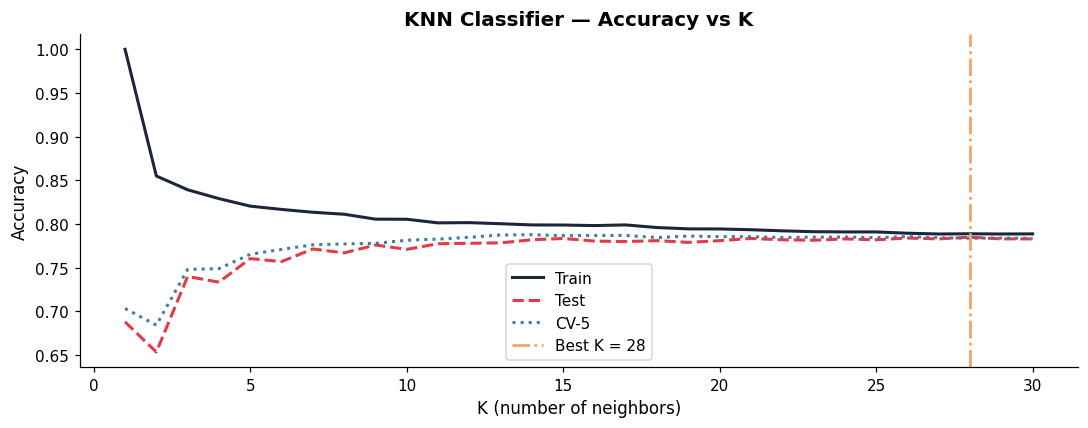

In [5]:
K_RANGE = range(1, 31)
train_acc, test_acc, cv_acc = [], [], []

for k in K_RANGE:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_c_sc, y_train_c)
    train_acc.append(accuracy_score(y_train_c, knn.predict(X_train_c_sc)))
    test_acc.append(accuracy_score(y_test_c,   knn.predict(X_test_c_sc)))
    cv_acc.append(cross_val_score(knn, X_train_c_sc, y_train_c, cv=5,
                                  scoring='accuracy').mean())

best_k_clf = K_RANGE.start + int(np.argmax(test_acc))
print(f'Best K (test accuracy) : {best_k_clf}  →  Accuracy = {max(test_acc):.4f}')

# ── Plot ────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(K_RANGE, train_acc, label='Train', color=C1, linewidth=2)
plt.plot(K_RANGE, test_acc,  label='Test',  color=C2, linewidth=2, linestyle='--')
plt.plot(K_RANGE, cv_acc,    label='CV-5',  color=C3, linewidth=2, linestyle=':')
plt.axvline(best_k_clf, color='#f4a261', linestyle='-.', linewidth=1.8,
            label=f'Best K = {best_k_clf}')
plt.xlabel('K (number of neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN Classifier — Accuracy vs K', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### 3-B · GridSearchCV — distance metric & weights

In [6]:
param_grid_clf = {
    'n_neighbors': list(range(1, 21)),
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan', 'minkowski']
}

gs_clf = GridSearchCV(
    KNeighborsClassifier(), param_grid_clf,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
gs_clf.fit(X_train_c_sc, y_train_c)

best_knn_clf  = gs_clf.best_estimator_
y_pred_clf    = best_knn_clf.predict(X_test_c_sc)
acc_clf       = accuracy_score(y_test_c, y_pred_clf)

print(f'Best params : {gs_clf.best_params_}')
print(f'CV accuracy : {gs_clf.best_score_:.4f}')
print(f'Test accuracy: {acc_clf:.4f}  ({acc_clf*100:.2f}%)')

Best params : {'metric': 'euclidean', 'n_neighbors': 17, 'weights': 'distance'}
CV accuracy : 0.7880
Test accuracy: 0.7760  (77.60%)


### 3-C · Evaluation plots — Classifier

In [7]:
print(classification_report(y_test_c, y_pred_clf, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

 Combination       0.38      0.11      0.17       294
         Dry       0.88      0.96      0.92       500
      Normal       0.73      0.87      0.79       617
        Oily       0.79      0.86      0.82       589

    accuracy                           0.78      2000
   macro avg       0.70      0.70      0.68      2000
weighted avg       0.73      0.78      0.74      2000



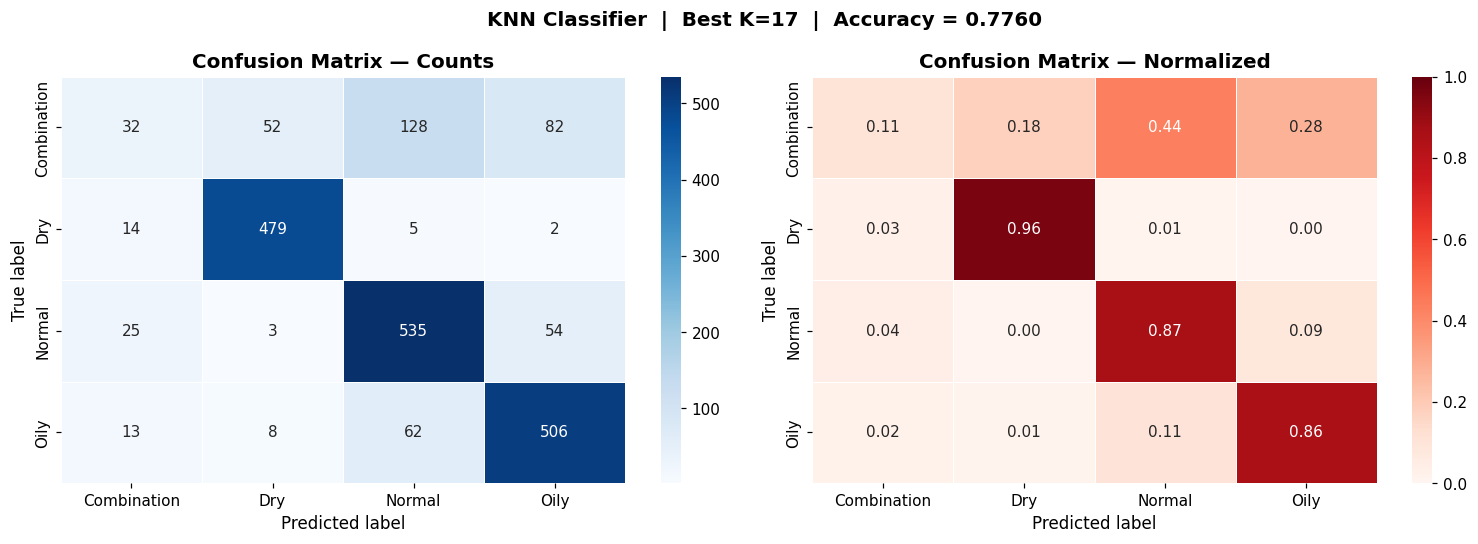

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Confusion matrix (counts) ────────────────────────────────────────────────
cm = confusion_matrix(y_test_c, y_pred_clf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='white')
axes[0].set_title('Confusion Matrix — Counts', fontweight='bold')
axes[0].set_ylabel('True label')
axes[0].set_xlabel('Predicted label')

# ── Confusion matrix (normalized) ───────────────────────────────────────────
cm_n = cm.astype(float) / cm.sum(axis=1)[:, None]
sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Reds', ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='white', vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix — Normalized', fontweight='bold')
axes[1].set_ylabel('True label')
axes[1].set_xlabel('Predicted label')

plt.suptitle(f'KNN Classifier  |  Best K={gs_clf.best_params_["n_neighbors"]}  |  Accuracy = {acc_clf:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

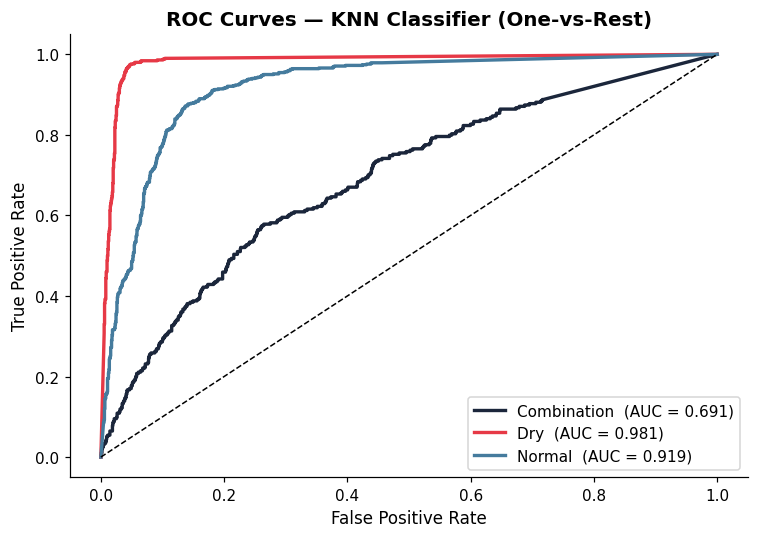

Macro-average AUC : 0.8824


In [9]:
from sklearn.preprocessing   import label_binarize
from sklearn.metrics         import roc_curve, auc, roc_auc_score

# Multiclass ROC (One-vs-Rest)
y_test_bin = label_binarize(y_test_c, classes=list(range(len(CLASS_NAMES))))
y_prob_clf = best_knn_clf.predict_proba(X_test_c_sc)

roc_colors = [C1, C2, C3]
plt.figure(figsize=(7, 5))

for i, (cls, col) in enumerate(zip(CLASS_NAMES, roc_colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_clf[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=col, linewidth=2.2,
             label=f'{cls}  (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — KNN Classifier (One-vs-Rest)', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

macro_auc = roc_auc_score(y_test_bin, y_prob_clf, multi_class='ovr', average='macro')
print(f'Macro-average AUC : {macro_auc:.4f}')

---
## 🅱️ Model B — KNN Regressor  →  `skin_score`

### 4-A · Finding the best K (RMSE Elbow)

Best K (min test RMSE) : 7  →  RMSE = 5.2454  |  R² = 0.9621


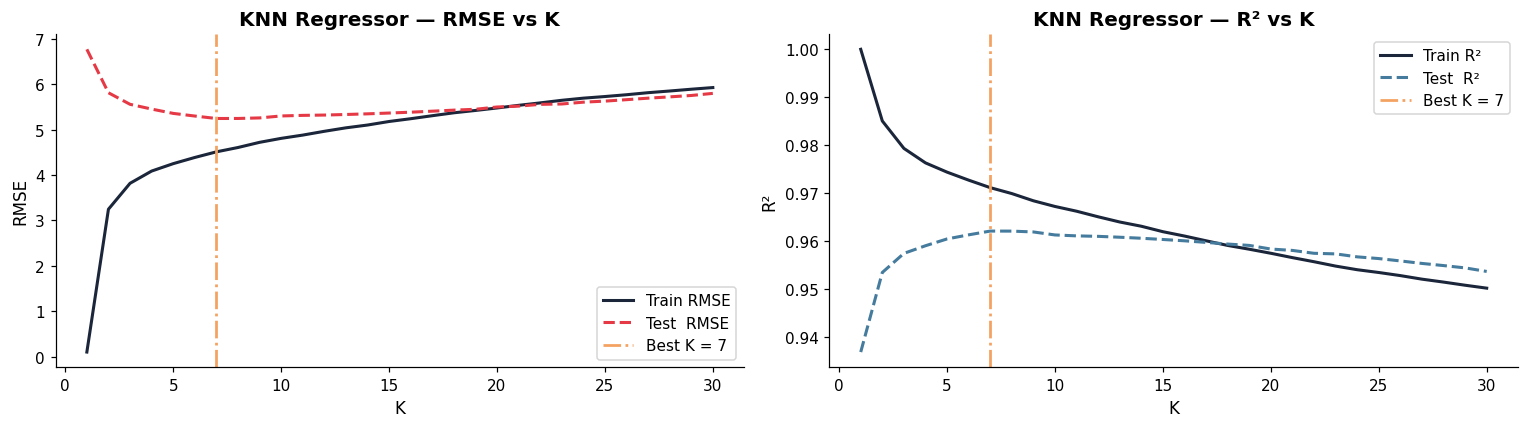

In [10]:
train_rmse, test_rmse, train_r2, test_r2 = [], [], [], []

for k in K_RANGE:
    knn_r = KNeighborsRegressor(n_neighbors=k)
    knn_r.fit(X_train_r_sc, y_train_r)
    pred_tr = knn_r.predict(X_train_r_sc)
    pred_te = knn_r.predict(X_test_r_sc)
    train_rmse.append(np.sqrt(mean_squared_error(y_train_r, pred_tr)))
    test_rmse.append(np.sqrt(mean_squared_error(y_test_r,  pred_te)))
    train_r2.append(r2_score(y_train_r, pred_tr))
    test_r2.append(r2_score(y_test_r,   pred_te))

best_k_reg = K_RANGE.start + int(np.argmin(test_rmse))
print(f'Best K (min test RMSE) : {best_k_reg}  →  RMSE = {min(test_rmse):.4f}  |  R² = {test_r2[best_k_reg-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# RMSE
axes[0].plot(K_RANGE, train_rmse, label='Train RMSE', color=C1, linewidth=2)
axes[0].plot(K_RANGE, test_rmse,  label='Test  RMSE', color=C2, linewidth=2, linestyle='--')
axes[0].axvline(best_k_reg, color='#f4a261', linestyle='-.', linewidth=1.8,
                label=f'Best K = {best_k_reg}')
axes[0].set_xlabel('K')
axes[0].set_ylabel('RMSE')
axes[0].set_title('KNN Regressor — RMSE vs K', fontweight='bold')
axes[0].legend()

# R²
axes[1].plot(K_RANGE, train_r2, label='Train R²', color=C1, linewidth=2)
axes[1].plot(K_RANGE, test_r2,  label='Test  R²', color=C3, linewidth=2, linestyle='--')
axes[1].axvline(best_k_reg, color='#f4a261', linestyle='-.', linewidth=1.8,
                label=f'Best K = {best_k_reg}')
axes[1].set_xlabel('K')
axes[1].set_ylabel('R²')
axes[1].set_title('KNN Regressor — R² vs K', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

### 4-B · GridSearchCV — distance metric & weights

In [11]:
param_grid_reg = {
    'n_neighbors': list(range(1, 21)),
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan', 'minkowski']
}

gs_reg = GridSearchCV(
    KNeighborsRegressor(), param_grid_reg,
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=0
)
gs_reg.fit(X_train_r_sc, y_train_r)

best_knn_reg = gs_reg.best_estimator_
y_pred_reg   = best_knn_reg.predict(X_test_r_sc)

rmse_reg = np.sqrt(mean_squared_error(y_test_r, y_pred_reg))
mae_reg  = mean_absolute_error(y_test_r, y_pred_reg)
r2_reg   = r2_score(y_test_r, y_pred_reg)

print(f'Best params : {gs_reg.best_params_}')
print(f'RMSE : {rmse_reg:.4f}')
print(f'MAE  : {mae_reg:.4f}')
print(f'R²   : {r2_reg:.4f}')

Best params : {'metric': 'euclidean', 'n_neighbors': 6, 'weights': 'distance'}
RMSE : 5.3275
MAE  : 3.5015
R²   : 0.9609


### 4-C · Evaluation plots — Regressor

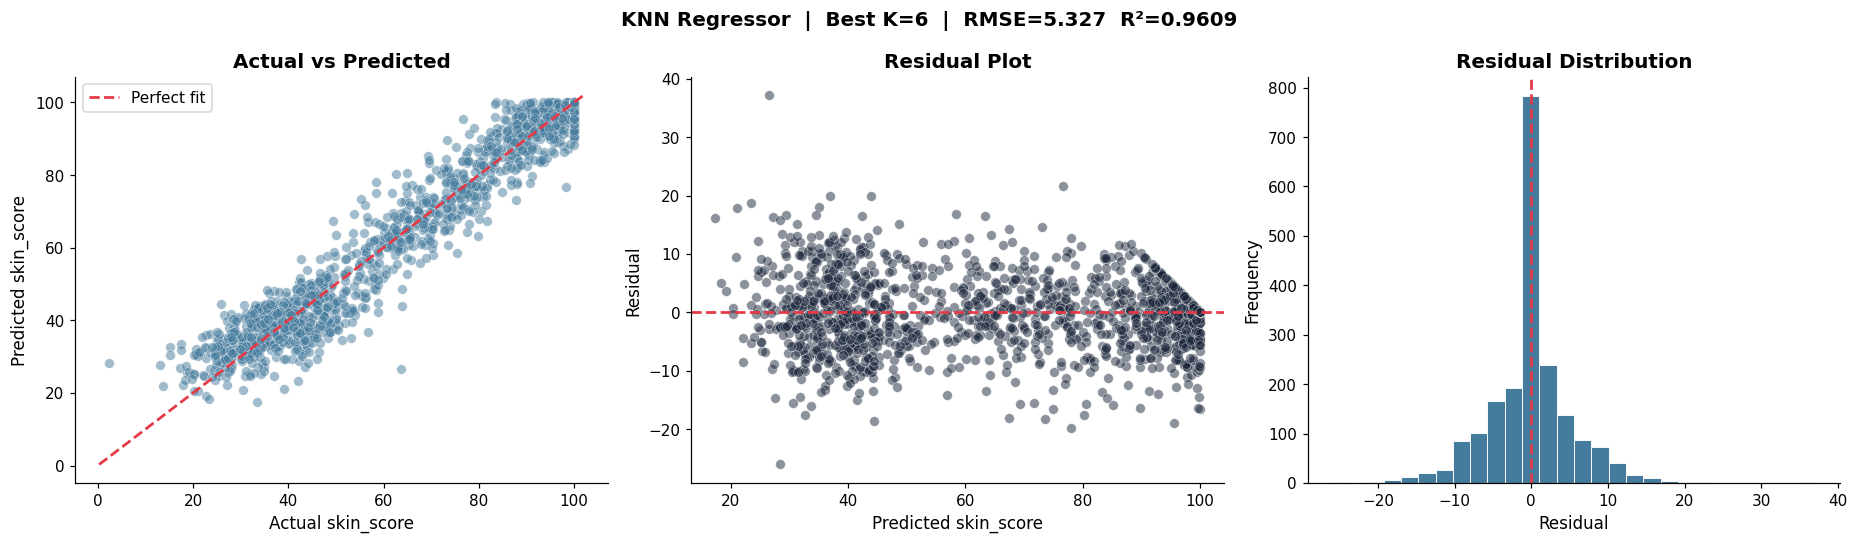

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Actual vs Predicted ──────────────────────────────────────────────────────
axes[0].scatter(y_test_r, y_pred_reg, alpha=0.5, color=C3, edgecolors='white',
                linewidth=0.4, s=40)
lims = [min(y_test_r.min(), y_pred_reg.min()) - 2,
        max(y_test_r.max(), y_pred_reg.max()) + 2]
axes[0].plot(lims, lims, '--', color=C2, linewidth=1.8, label='Perfect fit')
axes[0].set_xlabel('Actual skin_score')
axes[0].set_ylabel('Predicted skin_score')
axes[0].set_title('Actual vs Predicted', fontweight='bold')
axes[0].legend()

# ── Residuals ────────────────────────────────────────────────────────────────
residuals = y_test_r.values - y_pred_reg
axes[1].scatter(y_pred_reg, residuals, alpha=0.5, color=C1, edgecolors='white',
                linewidth=0.4, s=40)
axes[1].axhline(0, color=C2, linestyle='--', linewidth=1.8)
axes[1].set_xlabel('Predicted skin_score')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot', fontweight='bold')

# ── Residual distribution ────────────────────────────────────────────────────
axes[2].hist(residuals, bins=28, color=C3, edgecolor='white', linewidth=0.6)
axes[2].axvline(0, color=C2, linestyle='--', linewidth=1.8)
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution', fontweight='bold')

plt.suptitle(
    f'KNN Regressor  |  Best K={gs_reg.best_params_["n_neighbors"]}  |  '
    f'RMSE={rmse_reg:.3f}  R²={r2_reg:.4f}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

---
## ✅ Step 5 — Final Results Summary

In [13]:
# ── Summary table ────────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {
        'Model'   : 'KNN Classifier',
        'Target'  : 'Skin_Type',
        'Best K'  : gs_clf.best_params_['n_neighbors'],
        'Metric'  : gs_clf.best_params_['metric'],
        'Weights' : gs_clf.best_params_['weights'],
        'Accuracy': f"{acc_clf*100:.2f}%",
        'AUC (macro)': f"{macro_auc:.4f}",
        'RMSE'    : '—',
        'R²'      : '—'
    },
    {
        'Model'   : 'KNN Regressor',
        'Target'  : 'skin_score',
        'Best K'  : gs_reg.best_params_['n_neighbors'],
        'Metric'  : gs_reg.best_params_['metric'],
        'Weights' : gs_reg.best_params_['weights'],
        'Accuracy': '—',
        'AUC (macro)': '—',
        'RMSE'    : f"{rmse_reg:.4f}",
        'R²'      : f"{r2_reg:.4f}"
    }
])

print('='*70)
print('  KNN MODELS — FINAL RESULTS')
print('='*70)
print(summary.to_string(index=False))
print('='*70)

  KNN MODELS — FINAL RESULTS
         Model     Target  Best K    Metric  Weights Accuracy AUC (macro)   RMSE     R²
KNN Classifier  Skin_Type      17 euclidean distance   77.60%      0.8824      —      —
 KNN Regressor skin_score       6 euclidean distance        —           — 5.3275 0.9609


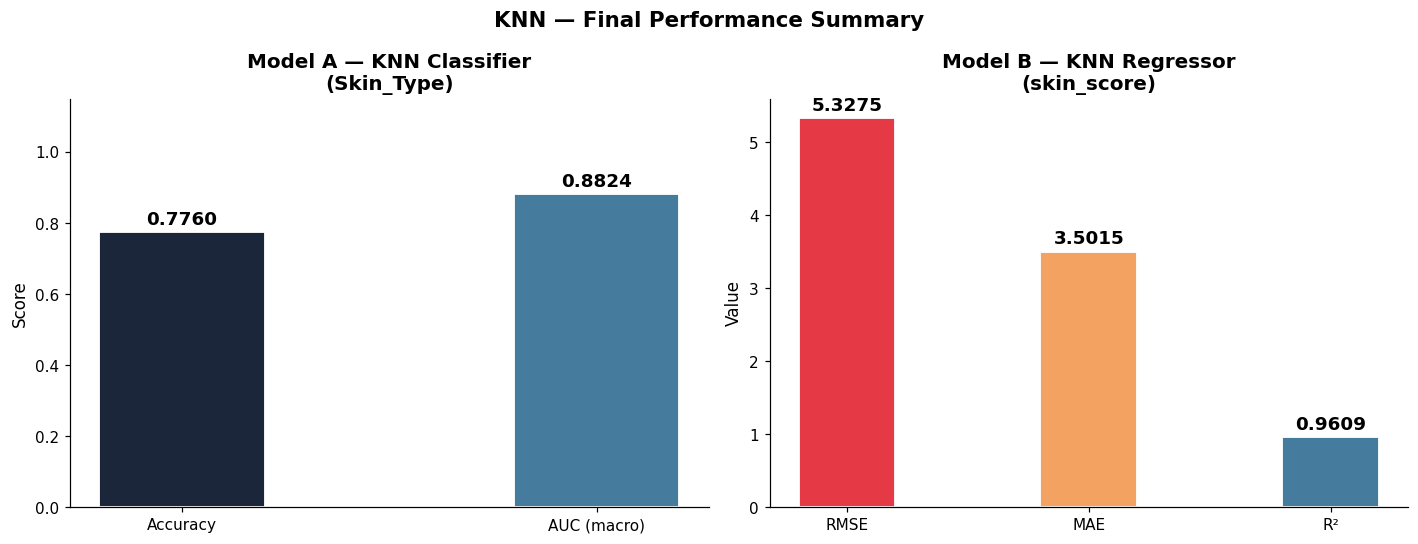

In [14]:
# ── Visual summary ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — Classifier metrics
metrics_clf = ['Accuracy', 'AUC (macro)']
values_clf  = [acc_clf, macro_auc]
bars = axes[0].bar(metrics_clf, values_clf,
                   color=[C1, C3], edgecolor='white', linewidth=1.2, width=0.4)
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Model A — KNN Classifier\n(Skin_Type)', fontweight='bold')
axes[0].set_ylabel('Score')
for bar, v in zip(bars, values_clf):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.02,
                 f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

# Right — Regressor metrics
metrics_reg = ['RMSE', 'MAE', 'R²']
values_reg  = [rmse_reg, mae_reg, r2_reg]
bar_colors  = [C2, '#f4a261', C3]
bars2 = axes[1].bar(metrics_reg, values_reg,
                    color=bar_colors, edgecolor='white', linewidth=1.2, width=0.4)
axes[1].set_title('Model B — KNN Regressor\n(skin_score)', fontweight='bold')
axes[1].set_ylabel('Value')
for bar, v in zip(bars2, values_reg):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + max(values_reg)*0.02,
                 f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('KNN — Final Performance Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()